<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_3280\2063286043.py:111: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xticklabels([f'$\mathbf{{{m}}}$' for m in all_metrics], fontsize=16)


Bar chart saved to: results/Figure1_model_bar_chart.png


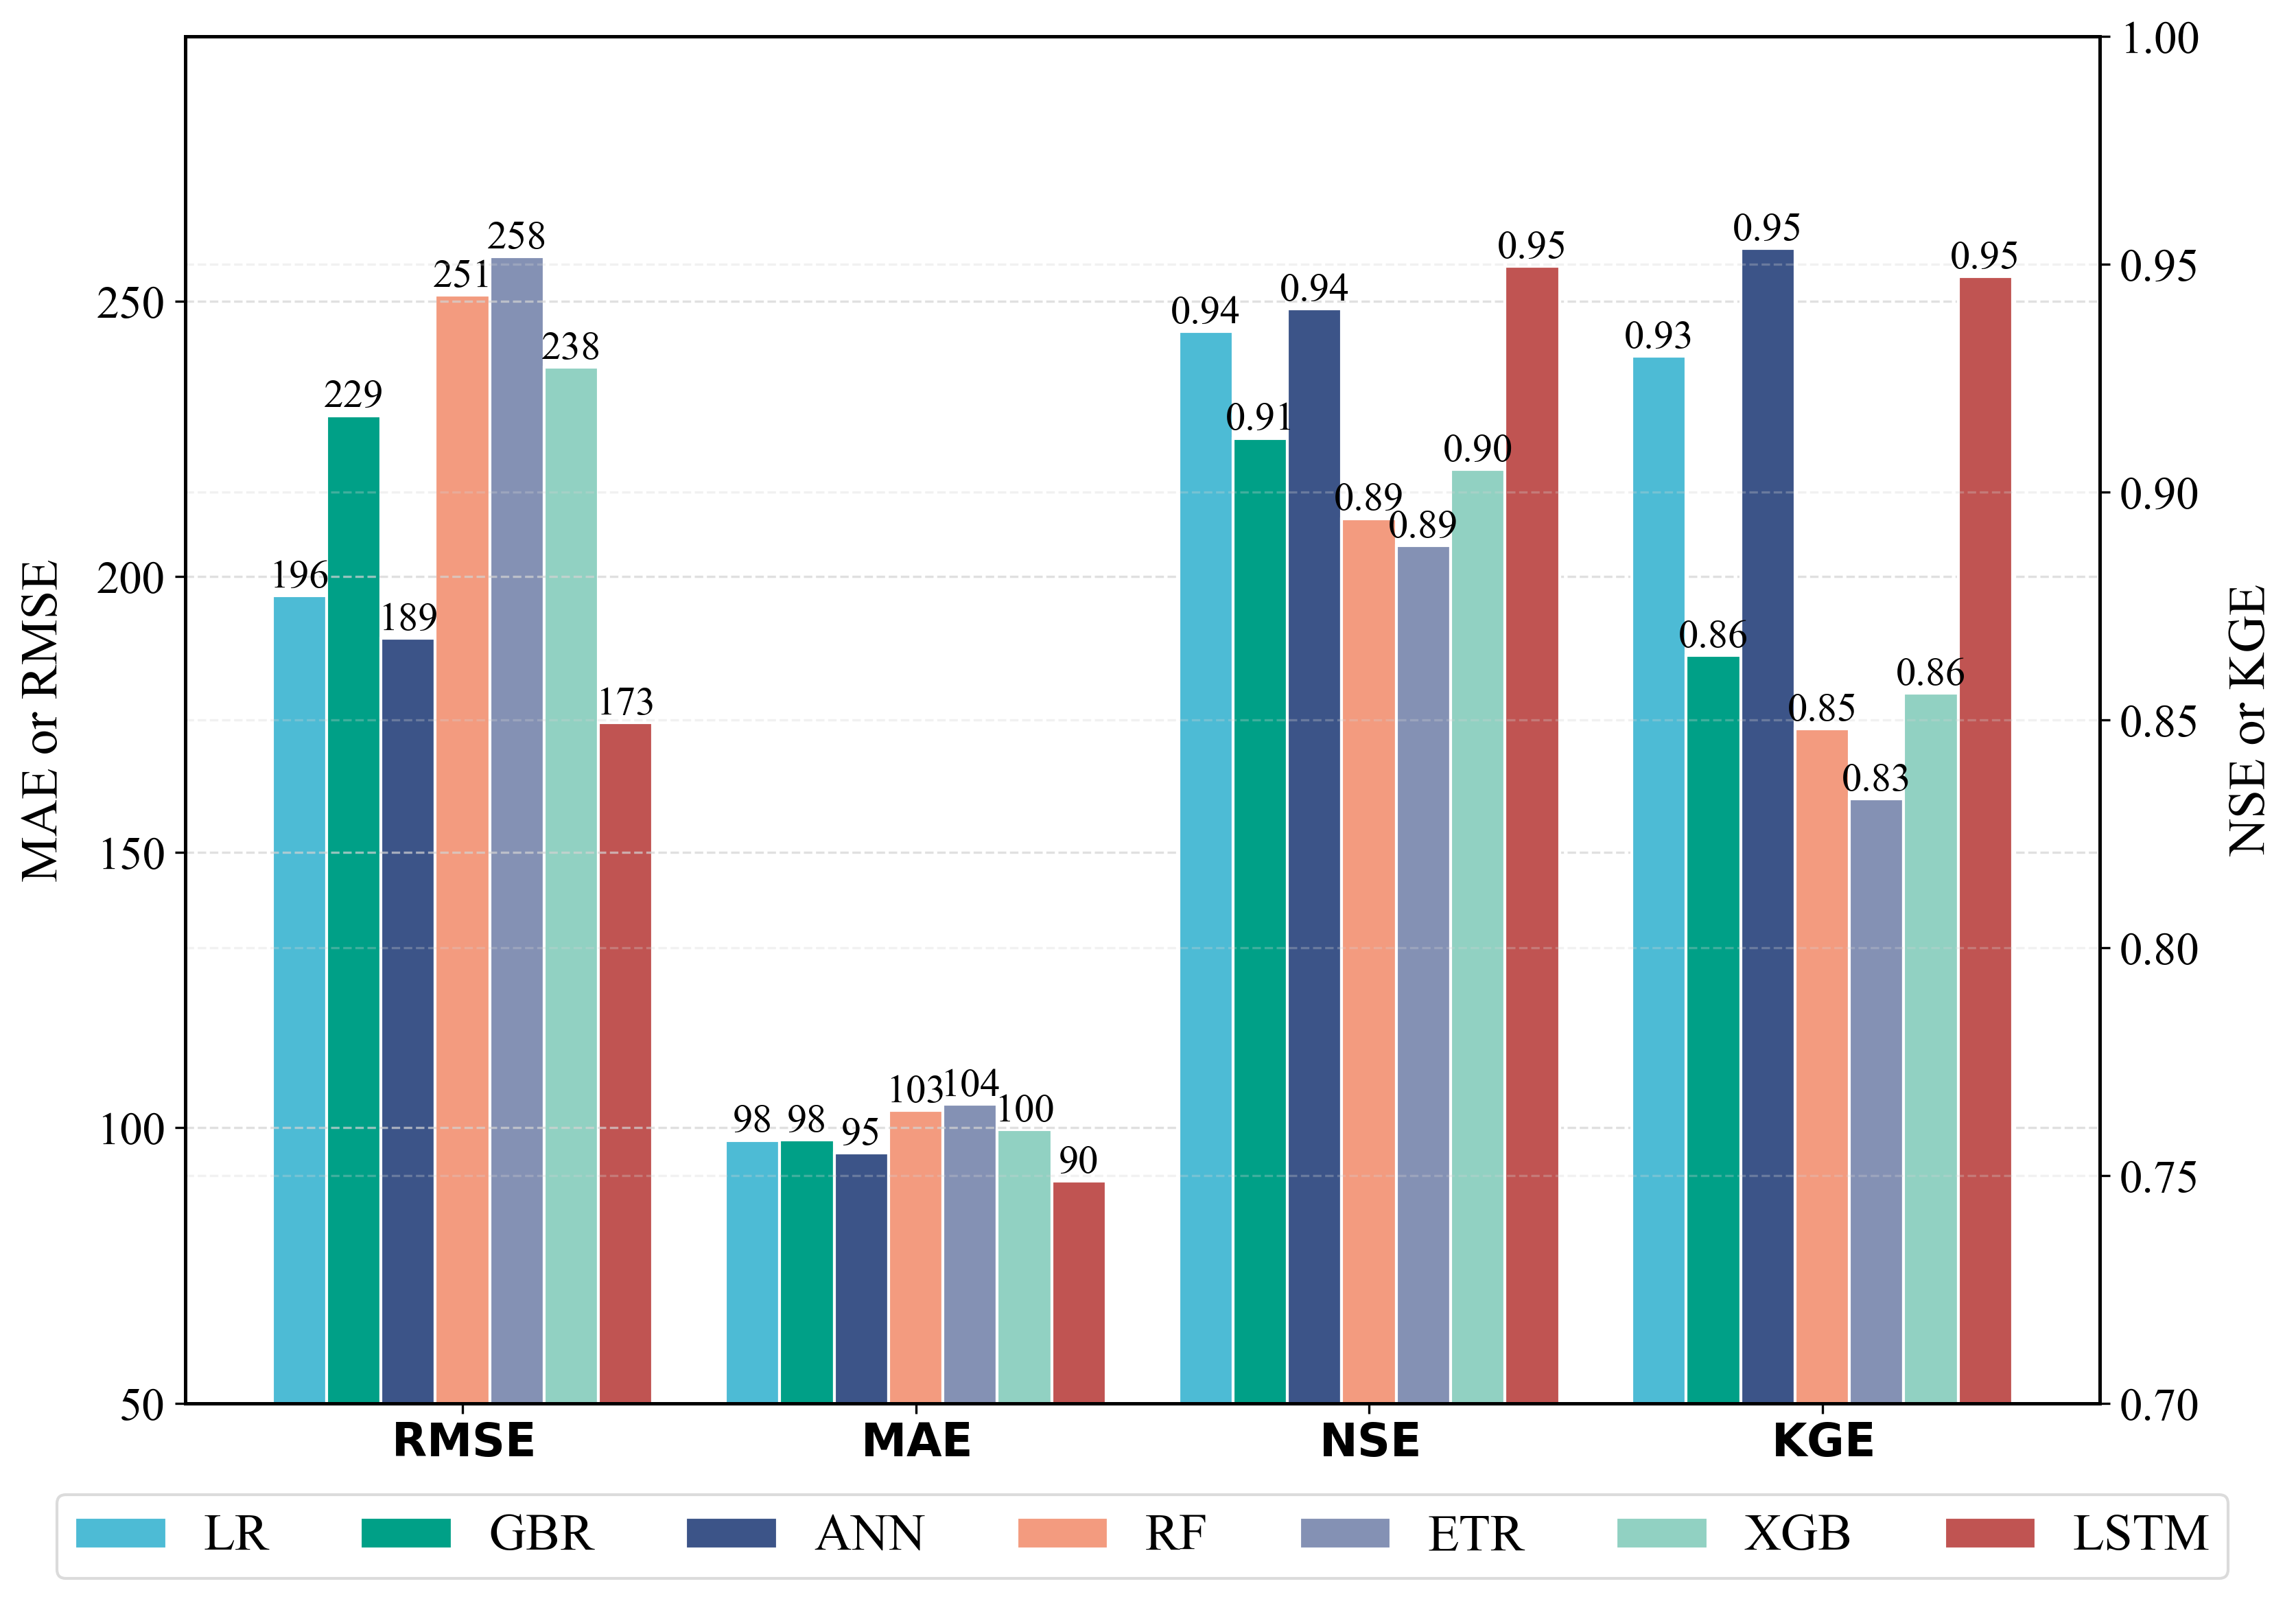

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import matplotlib.ticker as ticker

# 设置字体为英文罗马字体
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号
plt.rcParams["font.size"] = 16  # 稍微减小基础字体大小
plt.rcParams["axes.labelsize"] = 16  # 轴标签字体大小
plt.rcParams["axes.titlesize"] = 16  # 标题字体大小
plt.rcParams["legend.fontsize"] = 16  # 图例字体大小
plt.rcParams["xtick.labelsize"] = 16  # x轴刻度字体大小
plt.rcParams["ytick.labelsize"] = 16  # y轴刻度字体大小
plt.rcParams["axes.linewidth"] = 1.2  # 轴线条宽度
plt.rcParams["lines.linewidth"] = 2.0  # 线宽

def load_model_results(results_dir='results'):
    """加载所有模型的评估结果"""
    results = {}
    # 读取所有模型的对比结果
    with open(os.path.join(results_dir, 'all_models_comparison.json'), 'r') as f:
        all_results = json.load(f)
    
    # 提取每个模型的指标
    for model_name, data in all_results.items():
        results[model_name] = data['metrics']

    # 添加LSTM结果（根据实际训练结果修改数值）
    results['LSTM'] = {
        'RMSE': 173.44,  
        'MAE': 90.34,    
        'NSE': 0.9495,  
        'KGE': 0.9472   
    }
    
    
    return results

def plot_bar_chart(results, output_file='results/Figure1_model_bar_chart.png', 
                  figsize=(12, 8), dpi=300):  # 增大图表尺寸
    """绘制双y轴柱状图，同一指标的不同模型结果放在一组"""
    # 分离不同类型的指标
    error_metrics = ['RMSE', 'MAE']  # 误差指标，使用左y轴
    efficiency_metrics = ['NSE', 'KGE']  # 效率指标，使用右y轴
    all_metrics = error_metrics + efficiency_metrics
    
    # 获取模型名称
    models = list(results.keys())
    num_models = len(models)
    num_error = len(error_metrics)
    num_efficiency = len(efficiency_metrics)
    
    # 根据模型数量动态调整柱宽
    bar_width = 0.12 if num_models > 4 else 0.15
    
    # 设置柱状图的位置
    x_error = np.arange(num_error)  # 误差指标的位置
    x_efficiency = np.arange(num_error, num_error + num_efficiency)  # 效率指标的位置
    x = np.concatenate([x_error, x_efficiency])  # 所有指标的位置
    
    # 使用指定的专业颜色方案
    colors = ['#4DBBD5', '#00A087', '#3C5488', '#F39B7F', '#8491B4', '#91D1C2', '#E64B35']
    
    # 创建图形和主轴（左y轴）
    fig, ax1 = plt.subplots(figsize=figsize, dpi=dpi)
    
    # 创建副轴（右y轴），共享x轴
    ax2 = ax1.twinx()
    
    # 存储图例手柄
    legend_handles = []
    
    # 为每个模型绘制柱状图
    for i, model in enumerate(models):
        # 计算当前模型柱状图的位置偏移
        offset = - (num_models * bar_width) / 2 + i * bar_width + bar_width / 2
        
        # 绘制误差指标（RMSE, MAE）- 使用左y轴
        error_values = [results[model][metric] for metric in error_metrics]
        bars1 = ax1.bar(x_error + offset, error_values, width=bar_width, 
                       color=colors[i % len(colors)], edgecolor='white', linewidth=1)
        
        # 绘制效率指标（NSE, KGE）- 使用右y轴
        efficiency_values = [results[model][metric] for metric in efficiency_metrics]
        bars2 = ax2.bar(x_efficiency + offset, efficiency_values, width=bar_width,
                       color=colors[i % len(colors)], edgecolor='white', linewidth=1)
        
        # 只保存第一个模型的柱状图引用作为图例
        if i == 0:
            legend_handles.extend([bars1[0], bars2[0]])
        
        # 在柱状图顶部添加数值标签
        # 误差指标 - 整数显示
        for bar in bars1:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(round(height))}',
                    ha='center', va='bottom', rotation=0, fontsize=14)
        
        # 效率指标 - 两位小数显示
        for bar in bars2:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', rotation=0, fontsize=14)
    
    # 设置x轴标签
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'$\mathbf{{{m}}}$' for m in all_metrics], fontsize=16)
    
    # 设置坐标轴标签和标题
    ax1.set_ylabel('MAE or RMSE', fontsize=18, labelpad=10)  # 增加标签间距
    ax2.set_ylabel('NSE or KGE', fontsize=18, labelpad=10)
    
    # 添加图例，根据模型数量调整列数
    ncol = 7
    # 使用模型名称作为图例，每个模型对应一种颜色
    ax1.legend([plt.Rectangle((0,0),1,1, facecolor=colors[i%len(colors)], edgecolor='white') for i in range(num_models)],
              models,
              loc='upper center', bbox_to_anchor=(0.5, -0.05),
              ncol=ncol, frameon=True, edgecolor='lightgray', fancybox=True)
    plt.setp(ax1.get_legend().get_texts(), fontsize=18)
    
    # 添加网格线
    ax1.grid(axis='y', color='lightgray', linestyle='--', alpha=0.7)
    ax2.grid(axis='y', color='lightgray', linestyle='--', alpha=0.3)
    
    # 优化y轴范围，确保有足够空间显示顶部标签
    y1_min, y1_max = ax1.get_ylim()
    ax1.set_ylim(50, y1_max * 1.1)  # 增加顶部空间
    
    y2_min, y2_max = ax2.get_ylim()
    ax2.set_ylim(0.7, 1)  # 增加顶部空间
    
    
    # 调整整体布局，增加底部边距
    plt.subplots_adjust(bottom=0.05)  # 增加底部空间，防止标签被截断
    
    # 保存图像，确保所有元素都被包含
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', pad_inches=0.5)
    print(f"Bar chart saved to: {output_file}")
    
    # 显示图形
    plt.show()

if __name__ == "__main__":
    # 加载模型结果
    model_results = load_model_results()
    
    # 绘制柱状图
    plot_bar_chart(model_results)
    